# Data Loading and Augmentation Using PyTorch

**Course:** AI Capstone Project with Deep Learning (IBM) — Module 1

**Objective:** Build a custom PyTorch `Dataset`, wrap it in a `DataLoader`
with augmentation transforms, and compare it against `torchvision`'s
built-in `ImageFolder` dataset.

**Dataset:** `images_dataSAT/class_0_non_agri` and `images_dataSAT/class_1_agri`
(3,000 images each, 64x64 RGB).


## 1. Import libraries and packages

In [1]:
import time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, datasets
from PIL import Image

print("PyTorch:", torch.__version__)

torch.manual_seed(42)
np.random.seed(42)

DATA_DIR = Path("images_dataSAT")
assert DATA_DIR.exists(), f"'{DATA_DIR}' not found in the working directory."


PyTorch: 2.12.1+cu130


## 2. Custom PyTorch `Dataset`

The `Dataset` class defines *what the data is* and *how to get a single
item*. It doesn't handle batching, shuffling, or parallel loading itself —
that's the `DataLoader`'s job.


In [2]:
class SatelliteDataset(Dataset):
    """Custom PyTorch Dataset for the agricultural / non-agricultural
    satellite tile classification task."""

    def __init__(self, root_dir, transform=None):
        self.root_dir = Path(root_dir)
        self.transform = transform

        self.samples = []  # list of (path, label)
        class_map = {"class_0_non_agri": 0, "class_1_agri": 1}
        for class_name, label in class_map.items():
            for p in sorted((self.root_dir / class_name).glob("*.jpg")):
                self.samples.append((p, label))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        image = Image.open(path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, label


train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ToTensor(),  # scales to [0, 1] and reorders to (C, H, W)
])

eval_transform = transforms.Compose([
    transforms.ToTensor(),
])

custom_dataset = SatelliteDataset(DATA_DIR, transform=train_transform)
print(f"Custom dataset size: {len(custom_dataset)}")

img, label = custom_dataset[0]
print(f"Sample item -> tensor shape: {img.shape}, dtype: {img.dtype}, label: {label}")


Custom dataset size: 6000
Sample item -> tensor shape: torch.Size([3, 64, 64]), dtype: torch.float32, label: 0


## 3. Wrap it in a `DataLoader`

The `DataLoader` handles batching, shuffling, and (optionally) parallel
data loading via multiple worker processes.


In [3]:
train_loader = DataLoader(
    custom_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=0,  # 0 = main process only; safe default for small/CPU-only environments
)

print(f"Number of batches per epoch: {len(train_loader)}")

t0 = time.perf_counter()
batch_images, batch_labels = next(iter(train_loader))
t1 = time.perf_counter()

print(f"First batch -> images: {batch_images.shape}, labels: {batch_labels.shape}")
print(f"Time to produce first batch: {t1 - t0:.4f} s")


Number of batches per epoch: 188
First batch -> images: torch.Size([32, 3, 64, 64]), labels: torch.Size([32])
Time to produce first batch: 0.0154 s


## 4. Built-in `torchvision.datasets.ImageFolder`

For the common case of "one subfolder per class", `ImageFolder` provides a
ready-made, robust `Dataset` implementation — no need to write your own
directory-scanning logic.


In [4]:
imagefolder_dataset = datasets.ImageFolder(root=str(DATA_DIR), transform=train_transform)

print("Classes found:", imagefolder_dataset.classes)  # alphabetical: class_0_non_agri, class_1_agri
print("Class -> index mapping:", imagefolder_dataset.class_to_idx)
print(f"Total samples: {len(imagefolder_dataset)}")

imagefolder_loader = DataLoader(imagefolder_dataset, batch_size=32, shuffle=True, num_workers=0)

t0 = time.perf_counter()
if_batch_images, if_batch_labels = next(iter(imagefolder_loader))
t1 = time.perf_counter()
print(f"First batch -> images: {if_batch_images.shape}, labels: {if_batch_labels.shape}")
print(f"Time to produce first batch: {t1 - t0:.4f} s")


Classes found: ['class_0_non_agri', 'class_1_agri']
Class -> index mapping: {'class_0_non_agri': 0, 'class_1_agri': 1}
Total samples: 6000
First batch -> images: torch.Size([32, 3, 64, 64]), labels: torch.Size([32])
Time to produce first batch: 0.0144 s


## 5. Visualize augmented samples

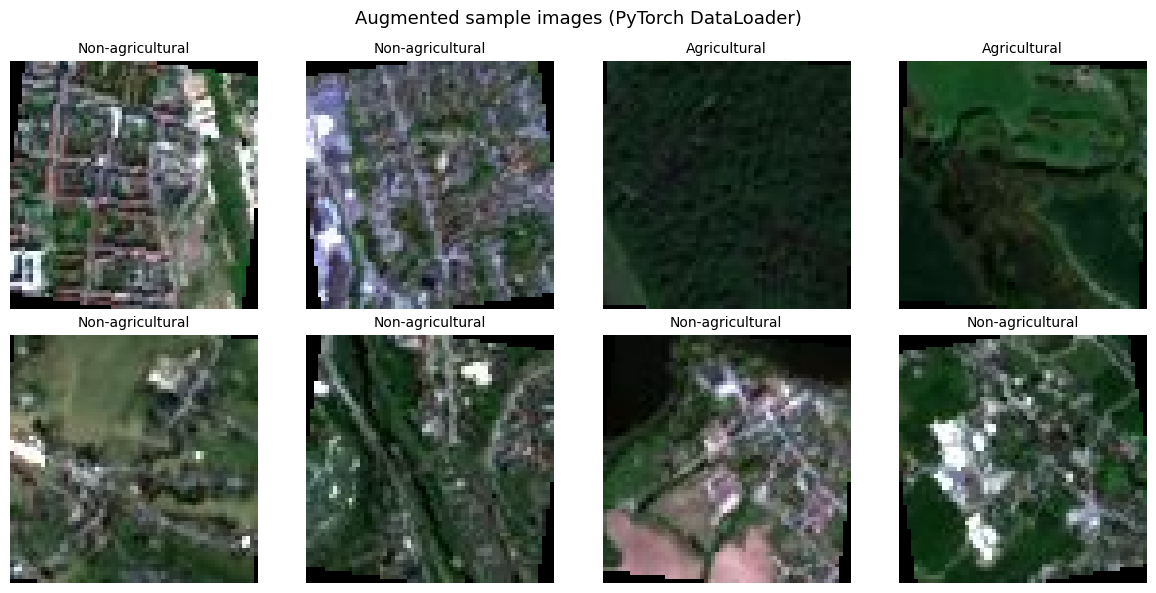

In [5]:
def denormalize_for_display(tensor_img):
    # tensor is (C, H, W) in [0, 1] -> convert to (H, W, C) numpy for imshow
    return tensor_img.permute(1, 2, 0).numpy()

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
class_names_idx = {v: k for k, v in imagefolder_dataset.class_to_idx.items()}

for ax, img, label in zip(axes.flat, batch_images[:8], batch_labels[:8]):
    ax.imshow(denormalize_for_display(img))
    label_str = "Agricultural" if label.item() == 1 else "Non-agricultural"
    ax.set_title(label_str, fontsize=10)
    ax.axis("off")

plt.suptitle("Augmented sample images (PyTorch DataLoader)", fontsize=13)
plt.tight_layout()
plt.show()


## 6. Custom `Dataset` vs. `ImageFolder` — comparison

| Aspect | Custom `Dataset` | `torchvision.datasets.ImageFolder` |
|---|---|---|
| Lines of code | More — you write the directory scan and label mapping yourself | Fewer — automatically infers classes from subfolder names |
| Flexibility | Full control (useful for non-standard directory layouts, multi-label data, etc.) | Assumes the standard "one folder per class" layout |
| Best for | Learning the mechanics; custom/complex data sources | The vast majority of standard image classification problems |

In both cases, the `DataLoader` is what actually makes the pipeline
efficient — handling batching, shuffling, and (with `num_workers > 0`)
parallel data loading, ready for training.


## Summary

This lab demonstrated PyTorch's data loading API and the separation of
concerns it's built around:

* The `Dataset` class defines *what the data is* and *how to get a single
  item*.
* The `DataLoader` class defines *how to iterate over the data*, handling
  batching, shuffling, and performance optimization.

Building a custom `Dataset` is an excellent way to understand the
underlying mechanics and is necessary for complex scenarios, while
`ImageFolder` provides a simple, robust solution for the vast majority of
image classification problems. In either case, the `DataLoader` is the
essential tool that makes the pipeline ready for training.
